In [7]:
import sys
!{sys.executable} -m pip uninstall numpy scikit-learn pandas -y
!{sys.executable} -m pip install numpy==1.26.4 pandas==2.2.2 scikit-learn==1.5.0 joblib matplotlib seaborn

  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached pandas-2.2.2-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached scikit_learn-1.5.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
Using cached pandas-2.2.2-cp312-cp312-win_amd64.whl (11.5 MB)
Using cached scikit_learn-1.5.0-cp312-cp312-win_amd64.whl (10.9 MB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.16.3 which is incompatible.
mlxtend 0.24.0 requires numpy>=2.3.5, but you have numpy 1.26.4 which is incompatible.
mlxtend 0.24.0 requires pandas>=2.3.3, but you have pandas 2.2.2 which is incompatible.
mlxtend 0.24.0 requires scikit-learn>=1.8.0, but you have scikit-learn 1.5.0 which is incompatible.


In [26]:
pip cache purge

Files removed: 694Note: you may need to restart the kernel to use updated packages.



In [29]:
pip install numpy==1.26.4 pandas==2.2.2 scikit-learn==1.5.0 joblib matplotlib seaborn

^C
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   -- ------------------------------------- 1.0/15.5 MB 6.3 MB/s eta 0:00:03
   ------- -------------------------------- 2.9/15.5 MB 7.6 MB/s eta 0:00:02
   ----------- ---------------------------- 4.5/15.5 MB 7.4 MB/s eta 0:00:02
   --------------- ------------------------ 6.0/15.5 MB 7.5 MB/s eta 0:00:02
   ------------------- -------------------- 7.6/15.5 MB 7.5 MB/s eta 0:00:02
   ---------------------- ----------------- 8.9/15.5 MB 7.2 MB/s eta 0:00:01
   -------------------------- ------------- 10.2/15.5 MB 7.0 MB/s eta 0:00:01
   ----------------------------- ---------- 11.5/15.5 MB 6.9 MB/s eta 0:00:01
   --------------------------------- ------ 12.8/15.5 MB 6.8 MB/s eta 0:00:01
   ------------------------------------- -- 14.4/15.5 MB 6.9 MB/s eta 0:00:01
   ---------------------------------------  15.5/15.5 MB 6.9 MB/s eta 0:00:01
   ---------------------------------------  15.5/15.5 MB 6.9 MB/s eta 0:00:

In [9]:
import sklearn
import numpy
import pandas

print(f"✅ Success!")
print(f"Sklearn version: {sklearn.__version__}")
print(f"NumPy version: {numpy.__version__}")

✅ Success!
Sklearn version: 1.5.0
NumPy version: 1.26.4


In [11]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# 设置随机种子，保证每次生成的数据一样
np.random.seed(42)

def generate_haircut_data(records=1000):
    data = []
    start_date = datetime(2025, 1, 1)

    for i in range(records):
        # 1. 随机生成日期
        current_date = start_date + timedelta(days=random.randint(0, 365), 
                                              hours=random.randint(9, 20))
        
        day_of_week = current_date.weekday() # 0=Mon, 6=Sun
        is_weekend = 1 if day_of_week >= 5 else 0
        hour = current_date.hour
        
        # 2. 模拟“拥挤度”逻辑 (Label)
        # 周末比较挤，下午 2点-5点比较挤
        base_demand = random.randint(1, 5)
        if is_weekend: base_demand += 4
        if 14 <= hour <= 17: base_demand += 3
        
        # 限制在 1-10 之间
        demand_level = min(10, base_demand)

        data.append([day_of_week, is_weekend, hour, demand_level])

    df = pd.DataFrame(data, columns=['day_of_week', 'is_weekend', 'hour', 'demand_level'])
    df.to_csv('haircut_demand.csv', index=False)
    print("✅ 成功生成 1000 条模拟数据：haircut_demand.csv")

if __name__ == "__main__":
    generate_haircut_data()

✅ 成功生成 1000 条模拟数据：haircut_demand.csv


Data Preview:


,day_of_week,is_weekend,hour,demand_level
0,2,0,13,1
1,1,0,10,1
2,1,0,13,1
3,4,0,10,2
4,6,1,12,6


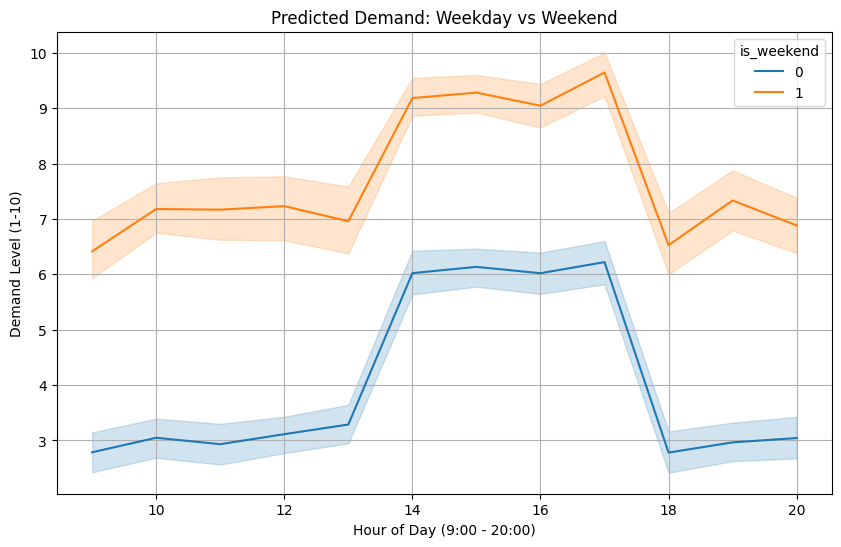

✅ AI Model 'haircut_ai_model.pkl' has been generated!


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import joblib

# 1. 加载并查看数据
df = pd.read_csv('haircut_demand.csv')
print("Data Preview:")
display(df.head())

# 2. 数据可视化（非常有益于论文截图）
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='hour', y='demand_level', hue='is_weekend')
plt.title('Predicted Demand: Weekday vs Weekend')
plt.xlabel('Hour of Day (9:00 - 20:00)')
plt.ylabel('Demand Level (1-10)')
plt.grid(True)
plt.show()

# 3. 训练模型
X = df[['day_of_week', 'is_weekend', 'hour']]
y = df['demand_level']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

# 4. 保存模型 (供 Django 调用)
joblib.dump(model, 'haircut_ai_model.pkl')
print("✅ AI Model 'haircut_ai_model.pkl' has been generated!")